# HRP Portfolio Benchmark

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / 'unsupervised_utils.py').exists():
        sys.path.insert(0, str(parent))
        break

from unsupervised_utils import *

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
returns = make_asset_returns(seed=147)
weights = hrp_weights(returns)
hrp = portfolio_backtest(returns, weights)
equal = portfolio_backtest(returns, pd.Series(1 / returns.shape[1], index=returns.columns))
bench = pd.DataFrame({'hrp': hrp['equity_curve'], 'equal_weight': equal['equity_curve']})
bench.to_parquet(OUTPUT / 'hrp_vs_equal_weight.parquet')
bench.tail()

,hrp,equal_weight
2026-05-04,1.0485,1.0684
2026-05-05,1.0489,1.0674
2026-05-06,1.0482,1.0671
2026-05-07,1.0473,1.0664
2026-05-08,1.0494,1.0683


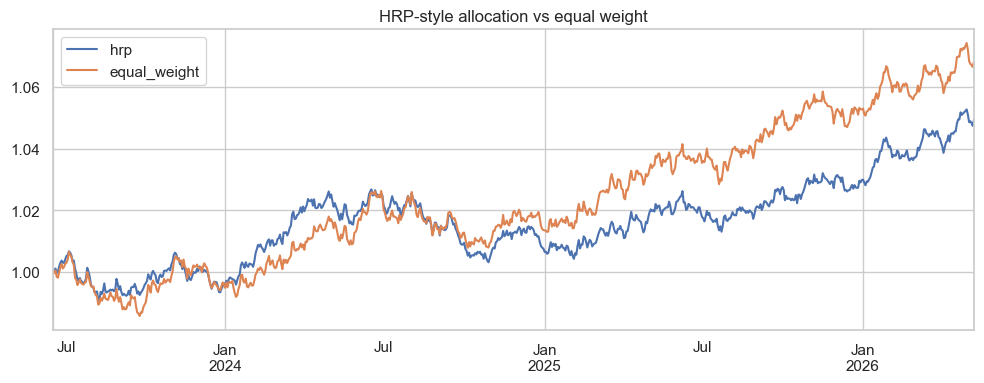

In [3]:
bench.plot(figsize=(10, 4), title='HRP-style allocation vs equal weight')
plt.tight_layout()